# **Importing necessary libraries**

In [28]:
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import f1_score, classification_report
from torch import nn
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

# **Loading dataset**

In [ ]:
df = pd.read_csv('Notebook\dataset.csv')

# **Exploratory Data Analysis-EDA**

In [30]:
# Displaying first 5 rows
df.head()

,subject,sender,receiver,timestamp,message_body,thread_id,email_types,email_status,email_criticality,product_types,agent_effectivity,agent_efficiency,customer_satisfaction
0,Mercury Language Documentation Issue,john.doe@example.com,support@aetheros.com,2023-10-26 10:02:34+00:00,"Hi Aetheros Support,\n\nI'm having trouble fin...",aa001-8e561ac9-8523-421f-9d05-e4c2a80a26d7,['inquiry'],ongoing,low,['Mercury Language'],high,very low,0.9043
1,Re: Mercury Language Documentation Issue,support@aetheros.com,john.doe@example.com,2023-10-27 14:15:22+00:00,"Dear John,\n\nThank you for reaching out to Ae...",aa001-8e561ac9-8523-421f-9d05-e4c2a80a26d7,['inquiry'],ongoing,low,['Mercury Language'],high,very low,0.9043
2,Re: Mercury Language Documentation Issue,john.doe@example.com,support@aetheros.com,2023-10-28 09:38:01+00:00,"Hi,\n\nI'm using Mercury version 2.3.5.\n\nTha...",aa001-8e561ac9-8523-421f-9d05-e4c2a80a26d7,['inquiry'],ongoing,low,['Mercury Language'],high,very low,0.9043
3,Re: Mercury Language Documentation Issue,john.doe@example.com,support@aetheros.com,2023-10-30 15:12:54+00:00,"Hi there,\n\nJust checking in on this. Have yo...",aa001-8e561ac9-8523-421f-9d05-e4c2a80a26d7,['inquiry'],ongoing,low,['Mercury Language'],high,very low,0.9043
4,URGENT: User Permission Errors in Production API,kenneth77@davis-becker.com,support@aetheros.com,2023-10-26 09:12:34+00:00,We are experiencing critical issues with user ...,aa001-550e8400-e29b-41d4-a716-446655440000,['issue'],completed,high,"['API Development', 'IAM service']",medium,very low,0.6918


In [31]:
# Displaying last 5 rows
df.tail()

,subject,sender,receiver,timestamp,message_body,thread_id,email_types,email_status,email_criticality,product_types,agent_effectivity,agent_efficiency,customer_satisfaction
2254,Re: URGENT: API Monitoring Not Reflecting IAM ...,support@aetheros.com,devon.barton@example.com,2023-10-27 14:58:12+00:00,Thank you for contacting Aetheros support. We ...,aa015-37e45f0b-172f-4b82-909c-43e61547a3e3,['issue'],completed,high,"['API monitoring', 'IAM service']",low,low,-0.0848
2255,Re: URGENT: API Monitoring Not Reflecting IAM ...,devon.barton@example.com,support@aetheros.com,2023-10-27 15:21:55+00:00,Our account ID is 84732. The affected users ar...,aa015-37e45f0b-172f-4b82-909c-43e61547a3e3,['issue'],completed,high,"['API monitoring', 'IAM service']",low,low,-0.0848
2256,Re: URGENT: API Monitoring Not Reflecting IAM ...,support@aetheros.com,devon.barton@example.com,2023-10-30 11:03:27+00:00,We have identified the issue. There seems to b...,aa015-37e45f0b-172f-4b82-909c-43e61547a3e3,['issue'],completed,high,"['API monitoring', 'IAM service']",low,low,-0.0848
2257,Re: URGENT: API Monitoring Not Reflecting IAM ...,devon.barton@example.com,support@aetheros.com,2023-10-30 11:15:42+00:00,"While we appreciate the update, the lack of ur...",aa015-37e45f0b-172f-4b82-909c-43e61547a3e3,['issue'],completed,high,"['API monitoring', 'IAM service']",low,low,-0.0848
2258,Re: URGENT: API Monitoring Not Reflecting IAM ...,support@aetheros.com,devon.barton@example.com,2023-11-01 15:32:01+00:00,We apologize for the delay. The issue has been...,aa015-37e45f0b-172f-4b82-909c-43e61547a3e3,['issue'],completed,high,"['API monitoring', 'IAM service']",low,low,-0.0848


In [32]:
# Shape of the dataframe
df.shape

(2259, 13)

In [33]:
# Checking for null values
df.isnull().sum()

,0
subject,0
sender,0
receiver,0
timestamp,0
message_body,0
thread_id,0
email_types,0
email_status,0
email_criticality,0
product_types,0


In [34]:
# Checking for the class imabalance
df['email_criticality'].value_counts()

,count
email_criticality,
high,934
medium,666
low,659


# **Data pre-processing**

In [35]:
# Removing all the rows other than email_criticality(target class) and message_body(feature)
df_refined = df[['message_body', 'email_criticality']].copy()

In [36]:
# Displaying the dataframe after removing irrelevant columns
df_refined.head()

,message_body,email_criticality
0,"Hi Aetheros Support,\n\nI'm having trouble fin...",low
1,"Dear John,\n\nThank you for reaching out to Ae...",low
2,"Hi,\n\nI'm using Mercury version 2.3.5.\n\nTha...",low
3,"Hi there,\n\nJust checking in on this. Have yo...",low
4,We are experiencing critical issues with user ...,high


In [37]:
# Label encoding target variables - Converting multiclassification probelm
# to binary classification problems by merging high and medium classes as High, encoded as 1
# and low as 0

df_refined['email_criticality'] = df_refined['email_criticality'].map({'low': 0, 'medium': 1, "high": 1})
df_refined

,message_body,email_criticality
0,"Hi Aetheros Support,\n\nI'm having trouble fin...",0
1,"Dear John,\n\nThank you for reaching out to Ae...",0
2,"Hi,\n\nI'm using Mercury version 2.3.5.\n\nTha...",0
3,"Hi there,\n\nJust checking in on this. Have yo...",0
4,We are experiencing critical issues with user ...,1
...,...,...
2254,Thank you for contacting Aetheros support. We ...,1
2255,Our account ID is 84732. The affected users ar...,1
2256,We have identified the issue. There seems to b...,1
2257,"While we appreciate the update, the lack of ur...",1


In [13]:
# Removing stopwords, punctuations and spaces from the feature
nlp = spacy.load('en_core_web_sm')

def tokenize_text(text):
    doc = nlp(text)
    token = [token.lemma_.lower()
             for token in doc
             if not token.is_stop
             and not token.is_punct
             and not token.is_space]
    return token


df_refined['message_body_tokens'] = df_refined['message_body'].apply(tokenize_text)

# **Visualization**

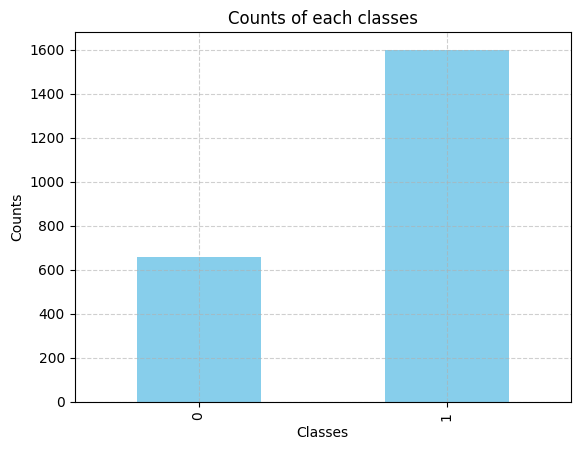

In [14]:
# Count of each classes using bar plot

data = df_refined['email_criticality'].value_counts().sort_index()
data.plot(kind='bar', color='skyblue')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Classes")
plt.ylabel("Counts")
plt.title("Counts of each classes")

plt.show()

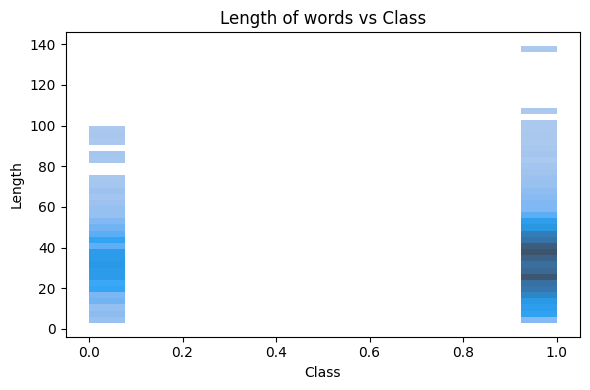

In [15]:
# Length of words against target variable
df_refined["word_length"] = df_refined['message_body_tokens'].apply(len)


plt.figure(figsize=(6, 4))
sns.histplot(y='word_length', x='email_criticality', data=df_refined)

plt.xlabel("Class")
plt.ylabel("Length")
plt.title("Length of words vs Class")
plt.tight_layout()
plt.show()

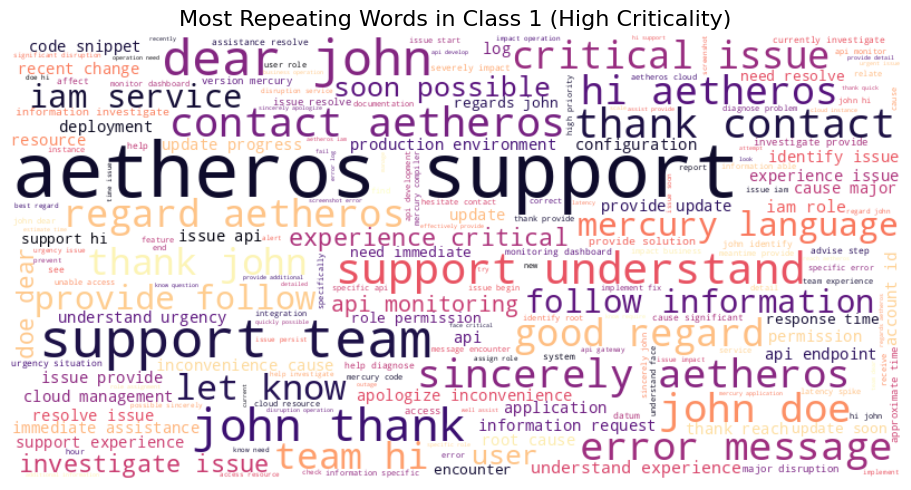

In [16]:
# Most Repeating Words in Class 1 (High Criticality)
class_1_words = ' '.join([' '.join(tokens) for tokens in df_refined[df_refined['email_criticality'] == 1]['message_body_tokens']])

if class_1_words.strip():
    word_cloud_1 = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(class_1_words)

    plt.figure(figsize=(10, 5))
    plt.imshow(word_cloud_1, interpolation='bilinear')
    plt.title('Most Repeating Words in Class 1 (High Criticality)', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# **Fine Tuning BERT model**

In [17]:
# Splitting the data into training set and testing set
train_df, test_df = train_test_split(
    df_refined,
    test_size=0.2,
    random_state=42,
    stratify=df_refined['email_criticality']
)

In [18]:
# BERT explicitly look for column name called label, so renaming email_criticality to label
training = Dataset.from_pandas(train_df[['message_body', 'email_criticality']]).rename_column("email_criticality", "labels")
testing = Dataset.from_pandas(test_df[['message_body', 'email_criticality']]).rename_column("email_criticality", "labels")

In [19]:
# Tokenize the dataset
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
  return tokenizer(examples['message_body'], padding=True, truncation=True)

training_tokens = training.map(tokenize_function, batched=True)
testing_tokens = testing.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1807 [00:00<?, ? examples/s]

Map:   0%|          | 0/452 [00:00<?, ? examples/s]

In [20]:
# Calculate class weights
class_count = train_df['email_criticality'].value_counts().sort_index().values
total_samples = len(train_df)
num_classes = len(class_count)

weights = total_samples / (class_count * num_classes)

# Converting weights to tensor
class_weight_tensor = torch.tensor(weights, dtype=torch.float)

In [21]:
# Downloadin the model for 2 labels
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
# Building custom weighted trainer
class Weighted_Trainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=None, num_items_in_batch=None):
      labels = inputs['labels']

      outputs = model(**inputs)
      logits = outputs.get("logits")

      device = logits.device
      loss_fn = nn.CrossEntropyLoss(weight=class_weight_tensor.to(device))
      loss = loss_fn(logits.view(-1, self.model.config.num_labels), labels.view(-1))

      return (loss, outputs) if return_outputs else loss

In [23]:
# Defining evaluation metrics
def compute_metric(eval_pred):
    logits, label = eval_pred

    predictions = np.argmax(logits, axis=1)

    # tracks balanced performance across both class
    macro_f1 = f1_score(label, predictions, average='macro')

    return {"f1": macro_f1}

In [24]:
# Configuring training aarguments
training_Args = TrainingArguments(
    output_dir="./bert_email_classifier",
    eval_strategy="epoch",
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available()
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
# Custom trainer usage
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Weighted_Trainer(
    model=model,
    args=training_Args,
    train_dataset=training_tokens,
    eval_dataset=testing_tokens,
    compute_metrics=compute_metric,
    data_collator=data_collator
)

In [26]:
print("Starting training")
trainer.train()

print("\nTraining Complete! Evaluating on the test set...")

predictions_output = trainer.predict(testing_tokens)
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

print("\n=== Final Test Set Classification Report ===")
print(classification_report(true_labels, preds, target_names=['Low Criticality (0)', 'High Criticality (1)']))

Starting training


Epoch,Training Loss,Validation Loss,F1
1,0.406833,0.430854,0.772018
2,0.505508,0.438302,0.785041
3,0.264762,0.520684,0.809637


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Training Complete! Evaluating on the test set...



=== Final Test Set Classification Report ===
                      precision    recall  f1-score   support

 Low Criticality (0)       0.73      0.73      0.73       132
High Criticality (1)       0.89      0.89      0.89       320

            accuracy                           0.84       452
           macro avg       0.81      0.81      0.81       452
        weighted avg       0.84      0.84      0.84       452



## Testing the Fine-Tuned Model

In [ ]:
import torch
import torch.nn.functional as F


def predict_email_criticality(email_text, model, tokenizer):
    # Ensure the model is in evaluation mode (turns off dropout layers)
    model.eval()

    inputs = tokenizer(
        email_text,
        return_tensors="pt",   
        truncation=True,
        padding="max_length",
        max_length=512
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.get("logits")

   
    probabilities = F.softmax(logits, dim=-1).squeeze().tolist()
    predicted_class = torch.argmax(logits, dim=-1).item()

    class_labels = {0: "Low Criticality", 1: "High Criticality"}

    print(f"\nEmail Analysis")
    print(f"Content snippet: '{email_text[:60]}...'")
    print(f"Prediction: {class_labels[predicted_class]}")
    print(f"Confidence Breakdown:")
    print(f" Low Criticality (0):  {probabilities[0]*100:.2f}%")
    print(f" High Criticality (1): {probabilities[1]*100:.2f}%")

    return predicted_class


email_low = "Hey team, when you will be back"
email_high = "Your product is worst one. Never works properly."

# Run the tests
predict_email_criticality(email_low, model, tokenizer)
predict_email_criticality(email_high, model, tokenizer)


--- Email Analysis ---
Content snippet: 'Hey team, when you will be back...'
Prediction: **Low Criticality**
Confidence Breakdown:
  - Low Criticality (0):  92.47%
  - High Criticality (1): 7.53%

--- Email Analysis ---
Content snippet: 'Your product is worst one. Never works properly....'
Prediction: **High Criticality**
Confidence Breakdown:
  - Low Criticality (0):  4.64%
  - High Criticality (1): 95.36%


1